In [1]:
!pip install groq -q

import os, json
os.makedirs("/root/.kaggle", exist_ok=True)

kaggle_credentials = {
    "username": "ishwarirautray",
    "key": "KGAT_c42443df0152824059832271ff3ac0e1"
}
with open("/root/.kaggle/kaggle.json", "w") as f:
    json.dump(kaggle_credentials, f)
os.chmod("/root/.kaggle/kaggle.json", 0o600)

!kaggle datasets download -d abdallahalidev/plantvillage-dataset
import zipfile
with zipfile.ZipFile("plantvillage-dataset.zip", "r") as zip_ref:
    zip_ref.extractall("plantvillage")
print("Dataset ready!")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 143.7/143.7 kB 6.7 MB/s eta 0:00:00
Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:11<00:00, 193MB/s]

Dataset ready!


In [2]:
from google.colab import files
os.makedirs("model", exist_ok=True)
print("Upload best_model.pth from your laptop...")
uploaded = files.upload()
import shutil
shutil.copy("best_model.pth", "model/best_model.pth")
print("Model ready!")

Upload best_model.pth from your laptop...


Saving best_model.pth to best_model.pth
Model ready!


In [3]:
import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
from PIL import Image
from groq import Groq
from google.colab import userdata
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
GROQ_API_KEY = userdata.get('GROQ_API_KEY')
client = Groq(api_key=GROQ_API_KEY)
print(f"Device: {device} | Groq ready!")

Device: cuda | Groq ready!


In [4]:
base_path = "plantvillage/plantvillage dataset/color"
dataset   = datasets.ImageFolder(base_path)
class_names = dataset.classes

ml_model = efficientnet_b0(weights=None)
ml_model.classifier[1] = nn.Linear(in_features=1280, out_features=38)
ml_model.load_state_dict(torch.load("model/best_model.pth", map_location=device))
ml_model = ml_model.to(device)
ml_model.eval()

print(f"ML model loaded! Classes: {len(class_names)}")

ML model loaded! Classes: 38


In [5]:
def predict_disease(image_path):
    """
    Takes image path → returns disease name + confidence
    """
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406],
                             std=[0.229, 0.224, 0.225])
    ])

    img = Image.open(image_path).convert("RGB")
    tensor = transform(img).unsqueeze(0).to(device)

    with torch.no_grad():
        outputs = ml_model(tensor)
        probs   = torch.softmax(outputs, dim=1)
        confidence, pred_idx = probs.max(1)

    raw_name   = class_names[pred_idx.item()]
    plant      = raw_name.split("___")[0].replace("_", " ")
    disease    = raw_name.split("___")[1].replace("_", " ")

    return {
        "plant":      plant,
        "disease":    disease,
        "confidence": round(confidence.item() * 100, 2),
        "raw_name":   raw_name
    }

print("predict_disease() ready!")

predict_disease() ready!


In [6]:
os.makedirs("agent", exist_ok=True)

disease_data = {
    "Apple Scab": {"cause": "Fungal infection caused by Venturia inaequalis",
                   "symptoms": "Dark olive-green spots on leaves, eventually turning brown and scabby",
                   "severity": "Medium"},
    "Late blight": {"cause": "Water mold Phytophthora infestans",
                    "symptoms": "Dark water-soaked lesions on leaves and stems, white mold on underside",
                    "severity": "High"},
    "Early blight": {"cause": "Fungal infection by Alternaria solani",
                     "symptoms": "Dark brown spots with concentric rings, yellow halo around spots",
                     "severity": "Medium"},
    "Powdery mildew": {"cause": "Various fungal species depending on host plant",
                       "symptoms": "White powdery coating on leaf surface, distorted young leaves",
                       "severity": "Low"},
    "Northern Leaf Blight": {"cause": "Fungal infection by Exserohilum turcicum",
                              "symptoms": "Long greyish-green lesions on corn leaves",
                              "severity": "Medium"},
    "Tomato Yellow Leaf Curl Virus": {"cause": "Virus transmitted by whitefly Bemisia tabaci",
                                      "symptoms": "Yellowing and upward curling of leaves",
                                      "severity": "High"},
    "healthy": {"cause": "No disease detected",
                "symptoms": "Plant appears healthy with no visible symptoms",
                "severity": "None"}
}

treatment_data = {
    "Apple Scab": {
        "organic":  ["Apply neem oil spray every 7-10 days",
                     "Use sulfur-based fungicide before infection",
                     "Remove and destroy fallen infected leaves"],
        "chemical": ["Apply Captan fungicide at bud break",
                     "Use Myclobutanil (Rally) during growing season",
                     "Spray Mancozeb every 7 days in wet conditions"],
        "prevention": "Plant resistant apple varieties, ensure good air circulation"
    },
    "Late blight": {
        "organic":  ["Apply copper-based fungicide immediately",
                     "Remove and destroy all infected plant parts",
                     "Avoid overhead irrigation — use drip instead"],
        "chemical": ["Apply Chlorothalonil (Daconil) at first sign",
                     "Use Mefenoxam (Ridomil) for soil drenching",
                     "Rotate with Cymoxanil for resistance management"],
        "prevention": "Use certified disease-free seeds, avoid wet foliage"
    },
    "Early blight": {
        "organic":  ["Apply neem oil or copper spray weekly",
                     "Mulch around base to prevent soil splash",
                     "Remove lower infected leaves immediately"],
        "chemical": ["Apply Chlorothalonil every 7-10 days",
                     "Use Azoxystrobin (Quadris) for systemic protection",
                     "Alternate fungicides to prevent resistance"],
        "prevention": "Crop rotation every 2-3 years, stake plants for airflow"
    },
    "Powdery mildew": {
        "organic":  ["Spray diluted baking soda solution (1 tbsp per litre)",
                     "Apply potassium bicarbonate spray",
                     "Use neem oil weekly as preventive"],
        "chemical": ["Apply Myclobutanil (Eagle) at first sign",
                     "Use Trifloxystrobin (Flint) for long protection",
                     "Spray Tebuconazole every 14 days"],
        "prevention": "Avoid over-fertilizing with nitrogen, improve air circulation"
    },
    "Northern Leaf Blight": {
        "organic":  ["Apply copper hydroxide spray at early infection",
                     "Remove heavily infected leaves",
                     "Ensure proper plant spacing for airflow"],
        "chemical": ["Apply Propiconazole (Tilt) at tasseling stage",
                     "Use Azoxystrobin + Propiconazole (Quilt) mixture",
                     "Spray Pyraclostrobin (Headline) for best control"],
        "prevention": "Plant resistant corn hybrids, rotate crops annually"
    },
    "Tomato Yellow Leaf Curl Virus": {
        "organic":  ["Use reflective silver mulch to repel whiteflies",
                     "Install yellow sticky traps around plants",
                     "Spray neem oil to reduce whitefly population"],
        "chemical": ["Apply Imidacloprid (Confidor) to control whiteflies",
                     "Use Thiamethoxam (Actara) as systemic insecticide",
                     "Spray Spiromesifen (Oberon) for whitefly larvae"],
        "prevention": "Use virus-resistant tomato varieties, remove infected plants immediately"
    },
    "healthy": {
        "organic":  ["Continue regular compost application",
                     "Use neem oil as preventive spray monthly",
                     "Maintain proper watering schedule"],
        "chemical": [],
        "prevention": "Regular monitoring, balanced fertilization, proper spacing"
    }
}

with open("agent/disease_data.json",   "w") as f:
    json.dump(disease_data, f, indent=2)
with open("agent/treatment_data.json", "w") as f:
    json.dump(treatment_data, f, indent=2)

def disease_info(disease_name):
    with open("agent/disease_data.json", "r") as f:
        data = json.load(f)
    if disease_name in data:
        info = data[disease_name]
        return {"disease": disease_name, "cause": info["cause"],
                "symptoms": info["symptoms"], "severity": info["severity"], "found": True}
    for key in data:
        if key.lower() in disease_name.lower() or disease_name.lower() in key.lower():
            info = data[key]
            return {"disease": key, "cause": info["cause"],
                    "symptoms": info["symptoms"], "severity": info["severity"], "found": True}
    return {"disease": disease_name, "cause": "Unknown",
            "symptoms": "Unknown", "severity": "Unknown", "found": False}

def treatment_advice(disease_name, farming_type="both"):
    with open("agent/treatment_data.json", "r") as f:
        data = json.load(f)
    matched_key = None
    if disease_name in data:
        matched_key = disease_name
    else:
        for key in data:
            if key.lower() in disease_name.lower() or disease_name.lower() in key.lower():
                matched_key = key
                break
    if not matched_key:
        return {"disease": disease_name, "organic": ["Consult local agricultural officer"],
                "chemical": ["Consult local agricultural officer"],
                "prevention": "No data available", "found": False}
    info   = data[matched_key]
    result = {"disease": matched_key, "prevention": info["prevention"], "found": True}
    if farming_type in ("organic", "both"):
        result["organic"]  = info["organic"]
    if farming_type in ("chemical", "both"):
        result["chemical"] = info["chemical"]
    return result

print("Both tools ready!")

Both tools ready!


In [7]:
def full_pipeline(image_path, farming_type="both"):
    """
    THE complete pipeline:
    Image → ML model → disease name → agent tools → diagnosis report
    """

    print(f"Step 1: Running ML model on image...")
    prediction = predict_disease(image_path)
    print(f"  Predicted: {prediction['disease']} ({prediction['confidence']}% confidence)")

    print(f"Step 2: Calling agent tools...")
    info      = disease_info(prediction["disease"])
    treatment = treatment_advice(prediction["disease"], farming_type)
    print(f"  Tools returned data for: {info['disease']}")

    print(f"Step 3: Generating expert report with Groq...")
    organic_str  = "\n".join([f"  - {t}" for t in treatment.get("organic", [])])
    chemical_str = "\n".join([f"  - {t}" for t in treatment.get("chemical", [])])

    system_prompt = """You are an expert agricultural advisor helping farmers
diagnose and treat crop diseases. Be concise, practical, and compassionate."""

    user_message = f"""
Plant: {prediction['plant']}
Disease detected: {prediction['disease']}
Model confidence: {prediction['confidence']}%

DISEASE INFO:
- Cause: {info['cause']}
- Symptoms: {info['symptoms']}
- Severity: {info['severity']}

TREATMENTS:
Organic:
{organic_str}

Chemical:
{chemical_str}

Prevention: {treatment['prevention']}

Write a complete diagnosis report for the farmer.
Include confidence level naturally in the response.
Under 200 words, structured clearly.
"""

    response = client.chat.completions.create(
        model="llama-3.3-70b-versatile",
        messages=[
            {"role": "system", "content": system_prompt},
            {"role": "user",   "content": user_message}
        ],
        max_tokens=400
    )

    report = response.choices[0].message.content

    return {
        "prediction": prediction,
        "info":       info,
        "treatment":  treatment,
        "report":     report
    }

print("full_pipeline() ready!")

full_pipeline() ready!


In [8]:
import random
random.seed(42)

sample_indices = random.sample(range(len(dataset)), 5)

for i, idx in enumerate(sample_indices):
    img_path, true_idx = dataset.samples[idx]
    true_name = class_names[true_idx].split("___")[1].replace("_", " ")

    print(f"\n{'='*65}")
    print(f"Image {i+1}/5 | True label: {true_name}")
    print('='*65)

    result = full_pipeline(img_path)

    print(f"\n{result['report']}")
    print(f"\n✓ Correct: {result['prediction']['disease'] == true_name}")


Image 1/5 | True label: Leaf Mold
Step 1: Running ML model on image...
  Predicted: Leaf Mold (100.0% confidence)
Step 2: Calling agent tools...
  Tools returned data for: Leaf Mold
Step 3: Generating expert report with Groq...

**Diagnosis Report: Tomato Leaf Mold**

We have identified Leaf Mold disease in your tomato plants with 100% confidence. Unfortunately, the underlying cause, symptoms, and severity of the disease are not well-documented in our system.

**Recommendations:**
To effectively manage the disease, we advise consulting with a local agricultural officer. They can provide personalized guidance on both organic and chemical treatment options tailored to your specific situation.

**Next Steps:**
Please reach out to your local agricultural officer to discuss the best course of action. They will be able to assess the severity of the disease and provide recommendations for treatment and prevention.

By working together with local experts, we can help you find a suitable solut

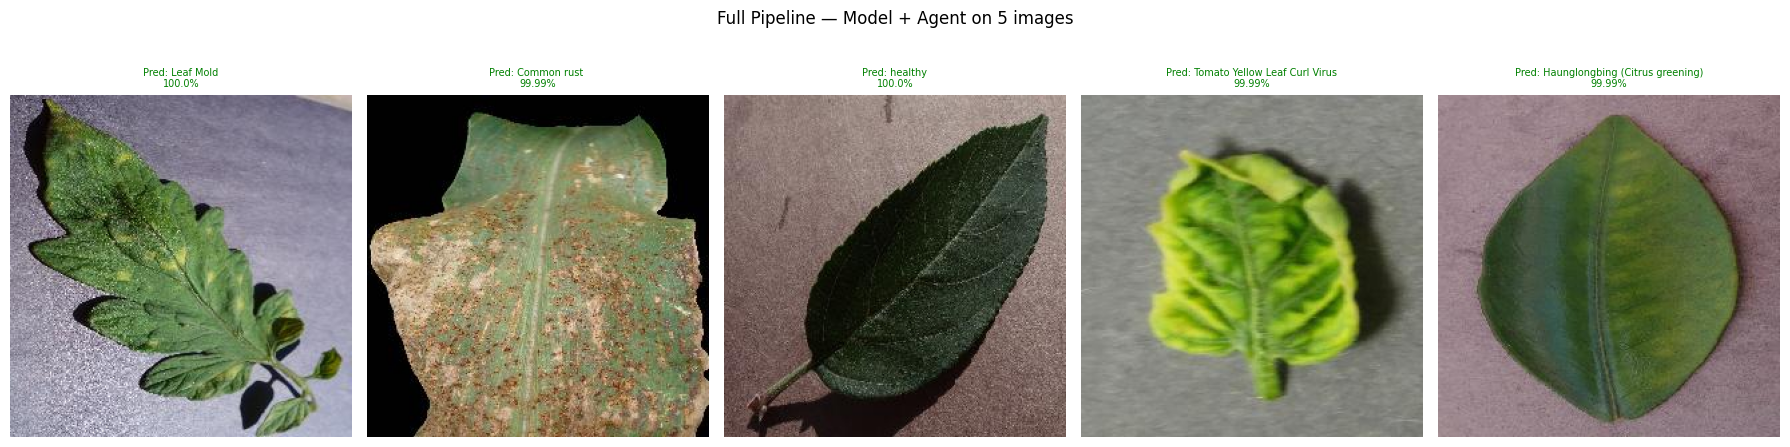

Done!


In [9]:
fig, axes = plt.subplots(1, 5, figsize=(18, 5))

for i, idx in enumerate(sample_indices):
    img_path, true_idx = dataset.samples[idx]
    true_name = class_names[true_idx].split("___")[1].replace("_", " ")

    prediction = predict_disease(img_path)
    match = prediction["disease"] == true_name

    img = Image.open(img_path).convert("RGB")
    axes[i].imshow(img)
    axes[i].set_title(
        f"Pred: {prediction['disease']}\n{prediction['confidence']}%",
        fontsize=7,
        color="green" if match else "red"
    )
    axes[i].axis("off")

plt.suptitle("Full Pipeline — Model + Agent on 5 images", fontsize=12)
plt.tight_layout()
plt.savefig("pipeline_results.png", dpi=150)
plt.show()
print("Done!")